In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
colors = ["#17BECF", "#E377C2", "#BCBD22"]
cmap = ListedColormap(colors)

import pickle
import pandas as pd

from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist

import sys
sys.path.append('code')
from align import *
from eval import *

# Load the data 

First, we load the synthetic data.

In [5]:
df = pd.read_csv('data/shapes_3d.csv')
data = df.to_numpy()
X = data[:,0:3]
labels = data[:,-1]
n = len(data)

X

array([[-0.06041   ,  0.31000678, -0.46812162],
       [ 0.86649375,  0.00743178, -0.04004044],
       [ 0.01135655,  0.31000678, -0.5502452 ],
       ...,
       [-0.26263288, -0.1318294 ,  0.50719034],
       [ 0.85014572,  0.47457782, -0.04004044],
       [-0.26263288, -0.79408339,  0.4779907 ]])

In this synthetic example, the data is in $\mathbb{R}^3$, so we can visualize the original data.

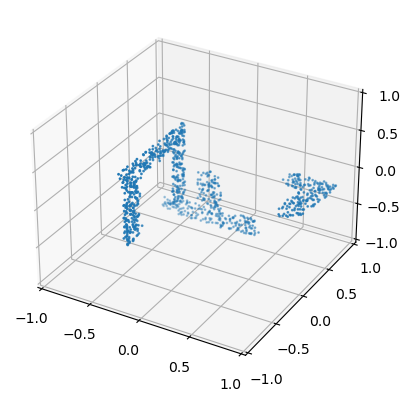

In [8]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:,0], data[:,1], data[:,2], s = 1)
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_zlim(-1,1)
ticks = np.arange(-1, 1.5, 0.5)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_zticks(ticks)
plt.show()

# Cluster + Embed method.

For the first step of the C+E method, any clustering method can then be used to cluster the data. In this example, we use DBSCAN.

In [10]:
db = DBSCAN(eps=0.1, min_samples=10)
clusters = db.fit_predict(data)

np.unique(clusters, return_counts = True)

(array([0, 1, 2], dtype=int64), array([296, 192, 512], dtype=int64))

Then, we embed each cluster individually using any method. Here we use PCA. 

In [11]:
pca  = PCA(n_components = 2)
embeddings = np.zeros((n,2))
for i in np.unique(clusters):
    embeddings[clusters == i] = pca.fit_transform(X[clusters == i,:])

Finally, we align the clusters. We compute the pairwise distances between objects in the original data, and the alignment will be done to preserve these distances. 

We first create an embedding object and set the tuning parameter $\alpha$. Alignment is done when `align_embedding` is called. Here, we set `m = 50` so that 50 points are sampled from each cluster at each iteration of alignment. Subsampling keeps the runtime of this step quite reasonable. 

In [12]:
#store distances in a dictionary for fast look up of between cluster distances 
distances = {}
n_clusters = len(np.unique(clusters))
for i in range(n_clusters):
    cluster_i = X[clusters == i,]
    for j in range(i+1, n_clusters):
        cluster_j = X[clusters == j,:]
        distances[i,j] = cdist(cluster_i, cluster_j)

In [13]:
out = Embedding(embeddings, clusters, distances, alpha =1.25)
ce_emb = out.align_embedding(m = 50)

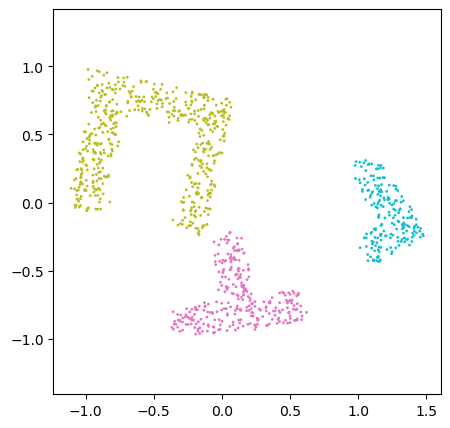

In [15]:
plt.figure(figsize = [5,5])
plt.scatter(ce_emb[:,0], ce_emb[:,1], c = labels, cmap = cmap, s = 1)
plt.axis('equal')
plt.show()